# Linear Memory


Demonstrate basic operations of a linear associative memory.


This notebook shows how to create a linear memory, store associations between item and context representations, and retrieve them. It demonstrates updating the memory, probing for stored patterns, and clearing associations.


In [ ]:
import os
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from jaxcmr.helpers import find_project_root
from jaxcmr.components.linear_memory import LinearMemory, init_mfc, init_mcf
from jaxcmr.state_analysis import matrix_heatmap
def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()


### Intialization

`LinearMemory` supports multiple initialization paths depending on modeling needs.

`LinearMemory.__init__` constructs a memory directly from a full weight matrix (`state`) and an `activation_scale`. This allows full control over initial associations.

In the CMR model, two linear memories are used; one to represent item-to-context associations and another for context-to-item associations. The `LinearMemory.init_mfc` method initializes the item-to-context memory, while `LinearMemory.init_mcf` initializes the context-to-item memory.

#### $M^{FC}$ Initialization

`LinearMemory.init_mfc` initializes an item-to-context memory where each item is associated with a unique context unit via strength `1 - learning_rate`. The weight matrix has shape `(item_count, context_feature_count)`. To support out-of-list context drift, set `context_feature_count = list_length + 2`.

Within CMR, we define `context_feature_count` in terms of the shape of the context representation the model is using. In our usual implementation, CMR uses one more context unit than the number of items in memory to allow for representation of a "start-of-list" context.

In [ ]:
figure_dir = "results/figures"
figure_str = ""
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)

item_count = 10
learning_rate = 0.1
activation_scale = 1.0
context_feature_count = item_count + 1

mfc = init_mfc(item_count, context_feature_count, learning_rate)

matrix_heatmap(mfc.state, figsize=(7, 5), annot_font_size=8, label_font_size=16)
plt.ylabel("Item Feature")
plt.xlabel("Context Feature");


AttributeError: 'float' object has no attribute 'size'

#### $M^{CF}$ Initialization

`LinearMemory.init_mcf` initializes a context-to-item memory. 

Initially, in-list context units are associated with all items according to shared_support.
They are also associated with a unique item according to item_support.
Start-of-list and out-of-list context units receive no initial associations.

To allow out-of-list contexts, set context_feature_count to `list_length + 2`.
Otherwise use `list_length+1`.

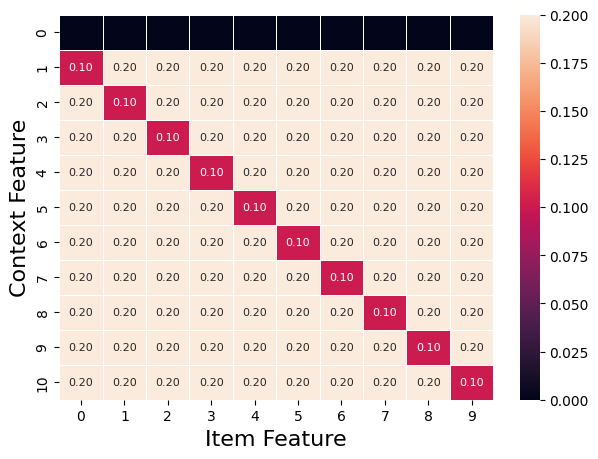

In [ ]:
item_count = 10
context_feature_count = item_count + 1
item_support = 0.1
shared_support = 0.2

mcf = LinearMemory.init_mcf(
    item_count, context_feature_count, item_support, shared_support
)

matrix_heatmap(mcf.state, figsize=(7, 5), annot_font_size=8, label_font_size=16)
plt.xlabel("Item Feature")
plt.ylabel("Context Feature");

### Association
Linear associative memories associate input and output patterns in a weight matrix according a [Hebbian learning rule](https://en.wikipedia.org/wiki/Hebbian_theory) where "neurons that figure to gether, wire together":

> $$w_{ij} = \sum_{k=1}^p x_i^k x_j^k $$
> 
> where $w_{ij}$ is the weight of the connection from neuron $j$ to neuron $i$, $p$ is the number of training patterns and $x_{i}^k$ the $k$-th input for neuron $i$.

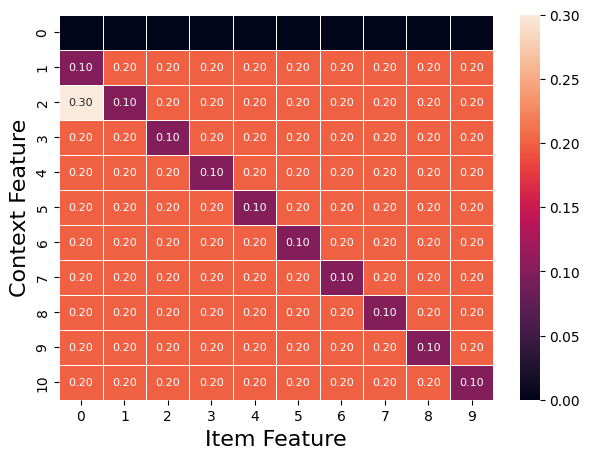

In [ ]:
items = jnp.eye(item_count)
contexts = jnp.eye(item_count, item_count + 1, 1)

mcf2 = mcf.associate(contexts[1], items[0], learning_rate)
matrix_heatmap(mcf2.state, figsize=(7, 5), annot_font_size=8, label_font_size=16)
plt.xlabel("Item Feature")
plt.ylabel("Context Feature");

### Probing
A dot product of the memory state and an input pattern retrieves an associated output pattern.

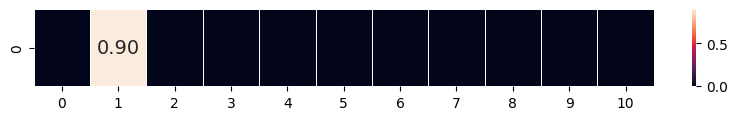

In [ ]:
memory = LinearMemory.init_mfc(item_count, item_count + 1, 0.1)

items = np.eye(item_count)

activation = memory.probe(items[0])

matrix_heatmap(np.expand_dims(activation, axis=0), figsize=(10, 1))
plt.xlabel("")
plt.ylabel("")
save_figure(figure_dir, figure_str)


`LinearMemory` implements the `typing.Memory` protocol. As long as a class implements this interface, it's usable by other classes that expect a `Memory` object. This allows for easy swapping of different memory implementations without changing the rest of the code.